# CS232 — Notebook 2 bản ×4: tách bạch "phương pháp" và "tỉ lệ phóng"

## Câu hỏi của notebook này

Notebook 2 gốc cho **BD-rate LPIPS −67,2%** ở tỉ lệ ×2 (540p→1080p). Notebook video SR sau đó chạy ở ×4 (270p→1080p) và chỉ đạt +6,0%, tức **thua baseline**.

Hai thí nghiệm khác nhau ở hai thứ cùng lúc: kiến trúc model (RRDBNet đơn ảnh so với BasicVSR chuỗi) và tỉ lệ phóng (×2 so với ×4). Không tách được yếu tố nào gây ra khác biệt.

Notebook này giữ **nguyên kiến trúc và nguyên phương pháp của notebook 2**, chỉ đổi ×2 thành ×4. Kết quả trả lời:

| Nếu ×4 cũng thắng baseline | Nếu ×4 thua baseline |
|---|---|
| Phương pháp là yếu tố chính, −67% chủ yếu nhờ train khớp degradation | **Tỉ lệ phóng là yếu tố chính**, −67% phần lớn nhờ chọn ×2 |

Đây là một **thí nghiệm khử biến** (ablation). Kết quả nào cũng dùng được cho báo cáo, vì nó cho biết phạm vi đúng của phát biểu.

## Giả thuyết trần độ phân giải

Ở ×4, ảnh gửi đi chỉ có 480×270 = 0,13 triệu pixel; ảnh đích 1080p có 2,07 triệu. Tức **94% pixel phải được sinh ra**, không có trong dữ liệu truyền đi.

Ở ×2 con số đó là 75%.

Khi bitrate đủ cao, ảnh LR gần như không còn artifact nén để sửa, và nút thắt chuyển từ *chất lượng nén* sang *độ phân giải*. Từ điểm đó trở đi, thêm bit không giúp gì cho pipeline SR, trong khi H.265 1080p vẫn tiếp tục tốt lên.

Dấu hiệu đã quan sát được ở notebook video SR: khi bitrate tăng 7,5 lần, LPIPS của H.265 cải thiện 3,7 lần còn của SR chỉ 1,4 lần.

**Notebook này kiểm chứng giả thuyết đó có đúng với RRDBNet không.**

## Những gì giữ nguyên từ notebook 2

- Kiến trúc RRDBNet 23 khối + U-Net discriminator
- Loss `L1 + 0.1·LPIPS + 0.005·RaGAN`
- Sinh dữ liệu bằng chính H.265 ở nhiều mức CRF
- Chia train/val theo clip
- Bộ metric PSNR-Y / SSIM / LPIPS / tLP và BD-rate

## Những gì đổi

| | Notebook 2 gốc | Bản này |
|---|---|---|
| Tỉ lệ | ×2 (960×540) | **×4 (480×270)** |
| Weights khởi tạo | RealESRGAN_x2plus | **RealESRGAN_x4plus** |
| Pixel unshuffle | Có (scale=2) | **Không** (scale=4) |
| CRF | 28–40 | 23–38 (ảnh nhỏ hơn) |
| Iterations | 40.000 → timeout | **8.000** (đã hội tụ từ 4.000) |
| Nền tảng | Kaggle | Colab + Drive |

Thời gian ước tính: sinh dữ liệu 40 phút, train 3,5 giờ, đánh giá 40 phút.

---
## Phần 1 — Kết nối Drive và cấu hình

### Cell dưới làm gì?
Mount Drive, kiểm tra GPU, tạo thư mục, tìm video nguồn.

### Tại sao cần?
Colab xoá sạch mọi thứ khi hết phiên. Drive giữ video nguồn, checkpoint và kết quả; ổ cục bộ `/content` giữ frame PNG vì đọc ghi hàng nghìn file nhỏ trên Drive rất chậm.

### Chuẩn bị trên Drive

```
MyDrive/CS232/
├── videos/      <- video 1080p
├── ckpt_x4/     <- notebook tự tạo
└── results_x4/  <- notebook tự tạo
```

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil, subprocess, json, math, time, random, glob
from pathlib import Path

DRIVE = Path("/content/drive/MyDrive/CS232")
for sub in ("videos","ckpt_x4","results_x4"):
    (DRIVE/sub).mkdir(parents=True, exist_ok=True)

WORK = Path("/content/work_x4"); WORK.mkdir(exist_ok=True)
DATA=WORK/"data"; EV=WORK/"eval"; FG=WORK/"figs"
CK = DRIVE/"ckpt_x4"
for d in (DATA,EV,FG): d.mkdir(parents=True, exist_ok=True)

def free_gb():
    st=os.statvfs("/content"); return st.f_bavail*st.f_frsize/1e9
print(f"Dia cuc bo con trong: {free_gb():.1f} GB")

import torch
assert torch.cuda.is_available(), "Runtime > Change runtime type > GPU"
gpu=torch.cuda.get_device_name(0)
print(f"GPU: {gpu}, {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
if "A100" in gpu: print("  Luu y: A100 tieu compute unit rat nhanh, T4/L4 la du.")

T_START=time.time(); BUDGET_H=11.0
def elapsed_h(): return (time.time()-T_START)/3600
def check_budget(t=""):
    e=elapsed_h(); print(f"[{e:.2f}h / {BUDGET_H}h] {t}"); return e<BUDGET_H

EXTS=("*.mp4","*.mkv","*.webm","*.mov","*.avi","*.MP4","*.MOV")
vids=sorted(sum([glob.glob(str(DRIVE/"videos"/e)) for e in EXTS], []))
print(f"\n{len(vids)} video trong Drive/CS232/videos/")
for v in vids[:10]: print(f"  {Path(v).name}  {os.path.getsize(v)/1e6:.0f} MB")
assert vids, "Upload video 1080p vao MyDrive/CS232/videos/"

Mounted at /content/drive
Dia cuc bo con trong: 202.2 GB
GPU: Tesla T4, 15.6 GB

5 video trong Drive/CS232/videos/
  11918864_1080_1920_50fps.mp4  10 MB
  11938123_1080_1920_50fps.mp4  11 MB
  12291834_1920_1080_30fps.mp4  422 MB
  13189433_3840_2160_60fps.mp4  185 MB
  15599342-hd_1080_1920_30fps.mp4  6 MB


### Cell dưới làm gì?
Import và đặt cấu hình.

### Tại sao cần?
Ba tham số thể hiện đúng những gì đã học được từ các lần chạy trước:

**`scale = 4`** — đây là biến duy nhất được đổi so với notebook 2. Mọi thứ khác giữ nguyên để so sánh có ý nghĩa.

**`iters = 8000`** — notebook 2 đặt 40.000 và bị timeout ở 28.000, trong khi validation LPIPS đã phẳng từ 4.000. Cải thiện từ 4.000 đến 28.000 chỉ 4,9%, nhỏ hơn biên độ dao động giữa các lần đo.

**`crf_list = [23,28,33,38]`** — dịch xuống so với 28–40 của bản ×2. Ảnh 270p nhỏ hơn 4 lần nên cùng một CRF cho ra bitrate thấp hơn nhiều; giữ nguyên dải cũ sẽ chỉ thấy toàn ảnh vỡ nát.

In [2]:
!pip install -q lpips 2>/dev/null
import numpy as np, cv2, torch.nn as nn, torch.nn.functional as F
import pandas as pd, matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from copy import deepcopy

DEVICE="cuda"
CFG = dict(
    scale = 4,                       # <<< BIEN DUY NHAT DOI so voi notebook 2
    hr=(1920,1080), fps=24,
    n_clips=8, clip_len=6, val_clips=2,
    crf_list=[23,28,33,38],
    preset_list=["fast","medium"],
    patch_lr=48,                     # 48*4=192 o HR, bang notebook 2
    batch=16,
    iters=8000,
    lr_G=1e-4, lr_D=1e-4,
    lam_lpips=0.10, lam_adv=0.005,
    ckpt_every=1000, log_every=100,
    eval_bitrates=[200,400,800,1500,3000],
    train_hours=4.0,
    seed=42,
)
S=CFG["scale"]; HRW,HRH=CFG["hr"]; LRW,LRH=HRW//S, HRH//S
random.seed(CFG["seed"]); np.random.seed(CFG["seed"]); torch.manual_seed(CFG["seed"])
torch.backends.cudnn.benchmark=True

def run(cmd,t=1800):
    r=subprocess.run(cmd,shell=True,capture_output=True,text=True,timeout=t)
    if r.returncode!=0: raise RuntimeError(f"{cmd}\n{r.stderr[-1200:]}")
    return r.stdout

HAS_VMAF = subprocess.run("ffmpeg -hide_banner -filters 2>/dev/null | grep -q libvmaf",
                          shell=True).returncode==0
print(run("ffmpeg -version | head -1").strip())
print(f"libvmaf: {'co' if HAS_VMAF else 'khong co (dung LPIPS)'}")
print(f"\nLR {LRW}x{LRH} -> HR {HRW}x{HRH}  (x{S})")
print(f"Ti le pixel phai sinh ra: {100*(1-1/S**2):.0f}%")
check_budget("setup xong")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.7 MB/s eta 0:00:00
ffmpeg version 6.1.1-3ubuntu5 Copyright (c) 2000-2023 the FFmpeg developers
libvmaf: khong co (dung LPIPS)

LR 480x270 -> HR 1920x1080  (x4)
Ti le pixel phai sinh ra: 94%
[0.00h / 11.0h] setup xong


True

---
## Phần 2 — Sinh dữ liệu

### Cell dưới làm gì?
Cắt clip, tạo ground truth 1080p, sinh bản LR 270p nén H.265 ở nhiều CRF và preset.

### Tại sao cần?
Đây là phần cốt lõi của phương pháp, giữ nguyên từ notebook 2: thay vì mô phỏng suy giảm bằng blur và noise tổng hợp, cho frame đi qua **đúng codec** sẽ dùng khi triển khai.

**Nhiều CRF** vì streaming dùng ABR, bitrate thay đổi liên tục — model phải bất biến với mức nén.

**Chia train/val theo clip, không theo frame** — hai frame liên tiếp gần như giống hệt nhau, chia theo frame sẽ gây rò rỉ dữ liệu và kết quả validation đẹp giả tạo.

In [3]:
HRD=DATA/"hr"; HRD.mkdir(exist_ok=True)
clips=[]; cid=0
nper=max(1, math.ceil(CFG["n_clips"]/len(vids)))
for v in vids:
    if cid>=CFG["n_clips"]: break
    try: dur=float(run(f'ffprobe -v error -show_entries format=duration -of csv=p=0 "{v}"').strip())
    except Exception: continue
    usable=dur-CFG["clip_len"]-2
    if usable<=2: continue
    for ss in np.linspace(1, usable, nper):
        if cid>=CFG["n_clips"]: break
        out=HRD/f"c{cid:02d}.mp4"
        if not out.exists():
            run(f'ffmpeg -y -loglevel error -ss {ss:.2f} -i "{v}" -t {CFG["clip_len"]} '
                f'-vf "scale={HRW}:{HRH}:flags=lanczos,fps={CFG["fps"]}" '
                f'-c:v libx264 -preset slow -crf 8 -pix_fmt yuv420p -an {out}', 600)
        clips.append(dict(id=cid, path=out)); cid+=1

random.Random(CFG["seed"]).shuffle(clips)
VAL=clips[:CFG["val_clips"]]; TRAIN=clips[CFG["val_clips"]:]
print(f"{len(clips)} clip | train {len(TRAIN)} | val {len(VAL)}")
print("val:", [c["path"].name for c in VAL])

def extract(video, outdir, vf=None):
    outdir=Path(outdir)
    if outdir.exists() and len(list(outdir.glob("*.png")))>0: return outdir
    outdir.mkdir(parents=True, exist_ok=True)
    vfa=f'-vf "{vf}"' if vf else ""
    run(f'ffmpeg -y -loglevel error -i "{video}" {vfa} "{outdir}"/%04d.png', 900)
    return outdir

PAIRS={"train":[], "val":[]}
for c in tqdm(clips, desc="sinh du lieu"):
    split = "val" if c in VAL else "train"
    gtd = extract(c["path"], DATA/f"gt{c['id']:02d}")
    gtf = sorted(gtd.glob("*.png"))
    for crf in CFG["crf_list"]:
        for pre in CFG["preset_list"]:
            tag=f"c{c['id']:02d}_crf{crf}_{pre}"
            lrv=DATA/f"lr_{tag}.mp4"
            if not lrv.exists():
                run(f'ffmpeg -y -loglevel error -i "{c["path"]}" '
                    f'-vf "scale={LRW}:{LRH}:flags=lanczos" -c:v libx265 -preset {pre} '
                    f'-crf {crf} -x265-params log-level=error -pix_fmt yuv420p -an "{lrv}"', 900)
            lrd=extract(lrv, DATA/f"lr_{tag}")
            lrf=sorted(lrd.glob("*.png"))
            for i in range(min(len(lrf), len(gtf))):
                PAIRS[split].append((str(lrf[i]), str(gtf[i]), crf))

print(f"\ncap (LR,HR): train {len(PAIRS['train']):,} | val {len(PAIRS['val']):,}")
print(f"dia con: {free_gb():.1f} GB")
check_budget("sinh du lieu xong")

8 clip | train 6 | val 2
val: ['c03.mp4', 'c04.mp4']


sinh du lieu:   0%|          | 0/8 [00:00<?, ?it/s]


cap (LR,HR): train 6,904 | val 2,304
dia con: 196.4 GB
[0.40h / 11.0h] sinh du lieu xong


True

### Cell dưới làm gì?
Hiển thị một cặp LR–HR, phóng to vùng nhiều chi tiết.

### Tại sao cần?
Kiểm tra bắt buộc trước khi train. Nếu LR không mang artifact nén rõ rệt thì mọi thứ phía sau vô nghĩa.

Ở ×4 cần chú ý thêm một điều: ảnh LR giờ chỉ 480×270 nên khi phóng lên so sánh, độ mờ do **thiếu độ phân giải** sẽ lấn át độ mờ do **nén**. Cần phân biệt hai thứ đó — ở CRF cao phải thấy được biên khối vuông, không chỉ là mờ đều.

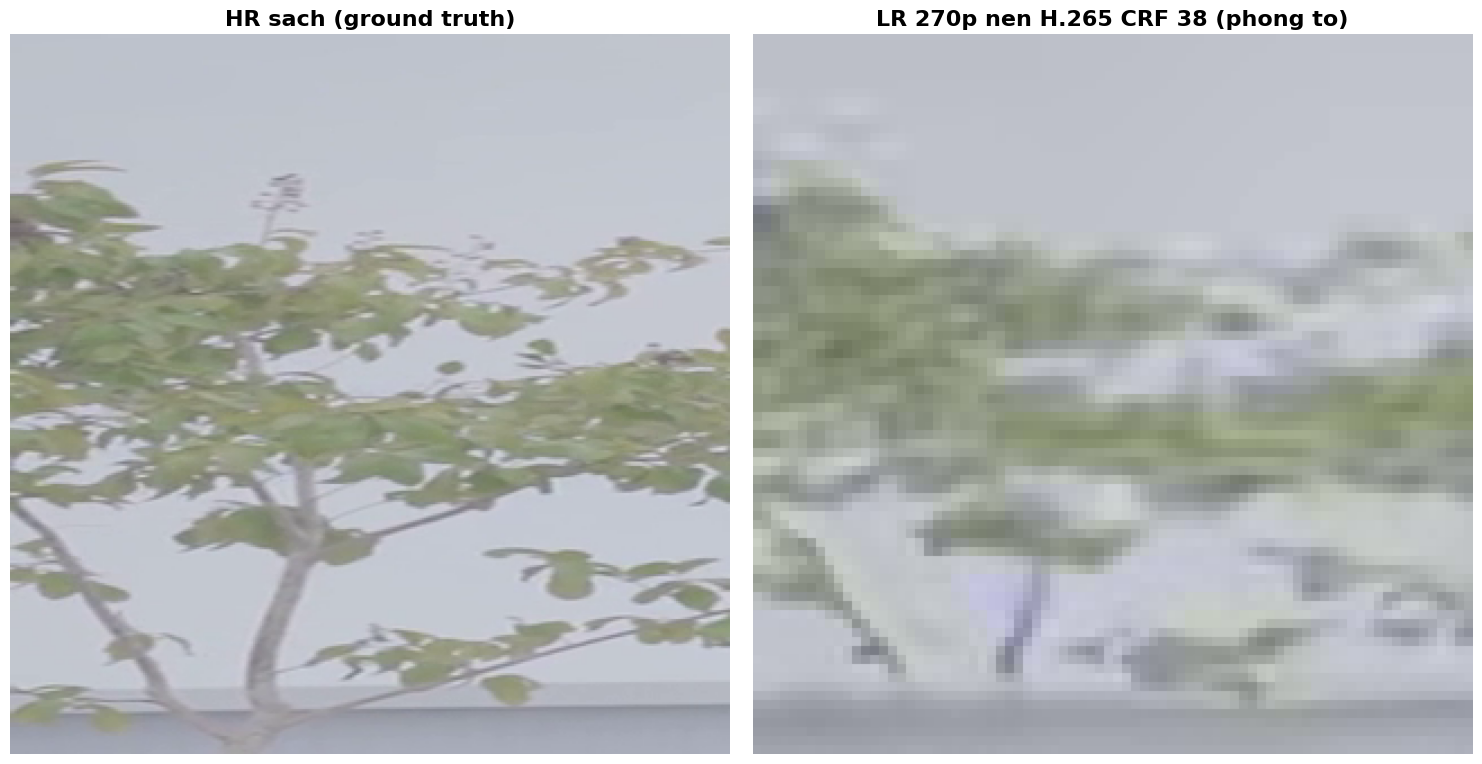

Can thay BIEN KHOI VUONG o CRF cao, khong chi la mo deu.
Neu chi mo deu -> do mo den tu thieu do phan giai chu khong phai nen.


In [4]:
def show_pair(lr_p, hr_p, crf, zoom=6, size=80):
    lr=cv2.imread(lr_p); hr=cv2.imread(hr_p)
    g=cv2.cvtColor(hr, cv2.COLOR_BGR2GRAY); best,pos=-1,(0,0)
    sz=size*S
    for y in range(0,g.shape[0]-sz,sz//2):
        for x in range(0,g.shape[1]-sz,sz//2):
            v=cv2.Laplacian(g[y:y+sz,x:x+sz],cv2.CV_64F).var()
            if v>best: best,pos=v,(y,x)
    y0,x0=pos
    lr_c=lr[y0//S:y0//S+size, x0//S:x0//S+size]
    lr_up=cv2.resize(lr_c,None,fx=zoom*S,fy=zoom*S,interpolation=cv2.INTER_NEAREST)
    hr_c=cv2.resize(hr[y0:y0+sz, x0:x0+sz],None,fx=zoom,fy=zoom,interpolation=cv2.INTER_NEAREST)
    fig,ax=plt.subplots(1,2,figsize=(15,7.5))
    for a,(t,im) in zip(ax,[("HR sach (ground truth)",hr_c),
                            (f"LR 270p nen H.265 CRF {crf} (phong to)",lr_up)]):
        a.imshow(im[:,:,::-1]); a.set_title(t,fontsize=16,fontweight="bold"); a.axis("off")
    plt.tight_layout(); plt.show()

hi=max(CFG["crf_list"])
show_pair(*random.choice([p for p in PAIRS["train"] if p[2]==hi]))
print("Can thay BIEN KHOI VUONG o CRF cao, khong chi la mo deu.")
print("Neu chi mo deu -> do mo den tu thieu do phan giai chu khong phai nen.")

---
## Phần 3 — Dataset và model

### Cell dưới làm gì?
Định nghĩa dataset cắt patch, kiến trúc RRDBNet, discriminator, và nạp weights ×4.

### Tại sao cần?

**Điểm khác biệt kỹ thuật duy nhất giữa ×2 và ×4 nằm ở `conv_first`.**

Ở ×2, Real-ESRGAN dùng `pixel_unshuffle` — thu nhỏ ảnh 2 lần và dồn thông tin vào 12 kênh, để 23 khối RRDB chạy ở độ phân giải một nửa cho nhanh. Sau đó hai lần phóng ×2 cho ra ×4, tổng lại là ×2.

Ở ×4 không cần thủ thuật đó: ảnh vào thẳng 3 kênh, hai lần phóng ×2 cho đúng ×4. Vì vậy `conv_first` nhận 3 kênh thay vì 12.

Code đã xử lý bằng biểu thức `in_ch * (4 if scale==2 else 16 if scale==1 else 1)`, nên chỉ cần đổi `scale` là đủ.

**Tên thuộc tính `rdb1..rdb3` và `conv1..conv5` không được đổi** — PyTorch sinh tên tham số từ tên biến, đặt sai một chữ là không nạp được weights.

In [5]:
class PairDataset(Dataset):
    def __init__(self, pairs, patch, scale, aug=True):
        self.pairs, self.p, self.s, self.aug = pairs, patch, scale, aug
    def __len__(self): return len(self.pairs)
    def __getitem__(self, i):
        lp,hp,crf = self.pairs[i]
        lr=cv2.imread(lp); hr=cv2.imread(hp)
        if lr is None or hr is None: return self[(i+1)%len(self)]
        p,s=self.p,self.s; h,w=lr.shape[:2]
        if h<p or w<p: return self[(i+1)%len(self)]
        y=random.randint(0,h-p); x=random.randint(0,w-p)
        a=lr[y:y+p, x:x+p]; b=hr[y*s:(y+p)*s, x*s:(x+p)*s]
        if b.shape[0]!=p*s or b.shape[1]!=p*s: return self[(i+1)%len(self)]
        if self.aug:
            if random.random()<0.5: a,b=a[:,::-1],b[:,::-1]
            if random.random()<0.5: a,b=a[::-1],b[::-1]
            if random.random()<0.5: a,b=np.rot90(a),np.rot90(b)
        t=lambda z: torch.from_numpy(np.ascontiguousarray(z[:,:,::-1]).astype(np.float32)/255.).permute(2,0,1)
        return t(a), t(b), crf

class RDB(nn.Module):
    def __init__(s, nf=64, gc=32):
        super().__init__()
        s.conv1=nn.Conv2d(nf,gc,3,1,1); s.conv2=nn.Conv2d(nf+gc,gc,3,1,1)
        s.conv3=nn.Conv2d(nf+2*gc,gc,3,1,1); s.conv4=nn.Conv2d(nf+3*gc,gc,3,1,1)
        s.conv5=nn.Conv2d(nf+4*gc,nf,3,1,1); s.act=nn.LeakyReLU(0.2, inplace=True)
    def forward(s,x):
        x1=s.act(s.conv1(x)); x2=s.act(s.conv2(torch.cat([x,x1],1)))
        x3=s.act(s.conv3(torch.cat([x,x1,x2],1))); x4=s.act(s.conv4(torch.cat([x,x1,x2,x3],1)))
        return s.conv5(torch.cat([x,x1,x2,x3,x4],1))*0.2 + x

class RRDB(nn.Module):
    def __init__(s, nf=64, gc=32):
        super().__init__(); s.rdb1,s.rdb2,s.rdb3=RDB(nf,gc),RDB(nf,gc),RDB(nf,gc)
    def forward(s,x): return s.rdb3(s.rdb2(s.rdb1(x)))*0.2 + x

class RRDBNet(nn.Module):
    def __init__(s, in_ch=3, out_ch=3, scale=4, nf=64, nb=23, gc=32):
        super().__init__(); s.scale=scale
        first = in_ch * (4 if scale==2 else 16 if scale==1 else 1)
        s.conv_first=nn.Conv2d(first, nf,3,1,1)
        s.body=nn.Sequential(*[RRDB(nf,gc) for _ in range(nb)])
        s.conv_body=nn.Conv2d(nf,nf,3,1,1)
        s.conv_up1=nn.Conv2d(nf,nf,3,1,1); s.conv_up2=nn.Conv2d(nf,nf,3,1,1)
        s.conv_hr=nn.Conv2d(nf,nf,3,1,1); s.conv_last=nn.Conv2d(nf,out_ch,3,1,1)
        s.act=nn.LeakyReLU(0.2, inplace=True)
    def forward(s,x):
        if s.scale==2:   f=F.pixel_unshuffle(x,2)
        elif s.scale==1: f=F.pixel_unshuffle(x,4)
        else:            f=x
        f=s.conv_first(f); f=f+s.conv_body(s.body(f))
        f=s.act(s.conv_up1(F.interpolate(f,scale_factor=2,mode="nearest")))
        f=s.act(s.conv_up2(F.interpolate(f,scale_factor=2,mode="nearest")))
        return s.conv_last(s.act(s.conv_hr(f)))

class UNetDiscriminator(nn.Module):
    def __init__(s, in_ch=3, nf=64):
        super().__init__(); sn=nn.utils.spectral_norm
        s.c0=nn.Conv2d(in_ch,nf,3,1,1)
        s.d1=sn(nn.Conv2d(nf,nf*2,4,2,1,bias=False)); s.d2=sn(nn.Conv2d(nf*2,nf*4,4,2,1,bias=False))
        s.d3=sn(nn.Conv2d(nf*4,nf*8,4,2,1,bias=False))
        s.u3=sn(nn.Conv2d(nf*8,nf*4,3,1,1,bias=False)); s.u2=sn(nn.Conv2d(nf*4,nf*2,3,1,1,bias=False))
        s.u1=sn(nn.Conv2d(nf*2,nf,3,1,1,bias=False))
        s.c1=sn(nn.Conv2d(nf,nf,3,1,1,bias=False)); s.c2=sn(nn.Conv2d(nf,nf,3,1,1,bias=False))
        s.out=nn.Conv2d(nf,1,3,1,1); s.act=nn.LeakyReLU(0.2, inplace=True)
    def forward(s,x):
        x0=s.act(s.c0(x)); x1=s.act(s.d1(x0)); x2=s.act(s.d2(x1)); x3=s.act(s.d3(x2))
        up=lambda z: F.interpolate(z,scale_factor=2,mode="bilinear",align_corners=False)
        y3=s.act(s.u3(up(x3)))+x2; y2=s.act(s.u2(up(y3)))+x1; y1=s.act(s.u1(up(y2)))+x0
        return s.out(s.act(s.c2(s.act(s.c1(y1)))))

# ---- nap weights x4plus ----
W4 = CK/"RealESRGAN_x4plus.pth"
if not W4.exists():
    run(f'wget -q --timeout=180 -O "{W4}" '
        f'"https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth"', 600)
    print(f"tai weights x4plus: {os.path.getsize(W4)/1e6:.1f} MB")

def build_G(pretrained=True):
    g=RRDBNet(scale=S)
    if pretrained:
        sd=torch.load(W4, map_location="cpu"); sd=sd.get("params_ema", sd.get("params", sd))
        miss=set(g.state_dict())-set(sd); extra=set(sd)-set(g.state_dict())
        bad=[k for k in g.state_dict() if k in sd and tuple(g.state_dict()[k].shape)!=tuple(sd[k].shape)]
        if miss or extra or bad:
            print(f"LECH: thieu {len(miss)} thua {len(extra)} shape {len(bad)}")
            if miss: print("  vd thieu:", sorted(miss)[:3])
            if bad:  print("  vd shape:", [(k, tuple(g.state_dict()[k].shape), tuple(sd[k].shape)) for k in bad[:3]])
            raise RuntimeError("Khong khop checkpoint")
        g.load_state_dict(sd, strict=True)
    return g.to(DEVICE)

G=build_G(); D=UNetDiscriminator().to(DEVICE)
print(f"Generator {sum(p.numel() for p in G.parameters())/1e6:.2f}M | "
      f"Discriminator {sum(p.numel() for p in D.parameters())/1e6:.2f}M")
with torch.no_grad():
    o=G(torch.rand(1,3,32,32,device=DEVICE))
print(f"Kiem tra scale: input 32x32 -> output {tuple(o.shape[-2:])} (can 128x128)")
assert o.shape[-1]==32*S, "Scale khong dung!"

train_ds=PairDataset(PAIRS["train"], CFG["patch_lr"], S, True)
val_ds  =PairDataset(PAIRS["val"],   CFG["patch_lr"], S, False)
train_dl=DataLoader(train_ds, batch_size=CFG["batch"], shuffle=True, num_workers=2,
                    pin_memory=True, drop_last=True, persistent_workers=True)
val_dl  =DataLoader(val_ds, batch_size=CFG["batch"], shuffle=False, num_workers=2)
xb,yb,cb=next(iter(train_dl))
print(f"batch LR {tuple(xb.shape)} HR {tuple(yb.shape)} | CRF {sorted(set(cb.tolist()))}")
check_budget("model san sang")

tai weights x4plus: 67.0 MB
Generator 16.70M | Discriminator 4.38M
Kiem tra scale: input 32x32 -> output (128, 128) (can 128x128)
batch LR (16, 3, 48, 48) HR (16, 3, 192, 192) | CRF [23, 28, 33, 38]
[0.40h / 11.0h] model san sang


True

---
## Phần 4 — Huấn luyện

### Cell dưới làm gì?
Huấn luyện generator với đúng loss của notebook 2: `L1 + 0.1·LPIPS + 0.005·RaGAN`.

### Tại sao giữ nguyên loss này?
Vì đây là biến cần **giữ cố định** để thí nghiệm có ý nghĩa. Notebook video SR đã cho thấy đổi loss làm kết quả lật ngược hoàn toàn — bỏ LPIPS thì LPIPS xấu đi 13,8%, thêm vào thì tốt lên. Nếu bản ×4 này dùng loss khác thì không tách được yếu tố nào nữa.

**RaGAN với `λ = 0.005`** rất nhỏ có chủ đích: adversarial mạnh khiến model bịa chi tiết. Với streaming ta muốn *nét hơn* chứ không muốn *khác đi*.

**Warm-up 10% đầu chỉ L1 + LPIPS** — bật GAN khi generator chưa ổn định dễ khiến discriminator thắng áp đảo và gradient của generator bị bóp nghẹt.

**EMA weights** — GAN dao động mạnh, bản trung bình trượt ổn định hơn và là bản dùng khi đánh giá.

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:04<00:00, 130MB/s]


train x4:   0%|          | 0/8000 [00:00<?, ?it/s]

/tmp/ipykernel_1462/2211069877.py:74: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  schedG.step(); update_ema(G_ema,G)
/tmp/ipykernel_1462/2211069877.py:79: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  adv=f"{float(l_adv):.3f}" if gan else "-")


  [it 1000] val LPIPS 0.2034
  [it 2000] val LPIPS 0.1980
  [it 3000] val LPIPS 0.1909
  [it 4000] val LPIPS 0.1780
  [it 5000] val LPIPS 0.1790
  [it 6000] val LPIPS 0.1836
  [it 7000] val LPIPS 0.1833
  [it 8000] val LPIPS 0.1776


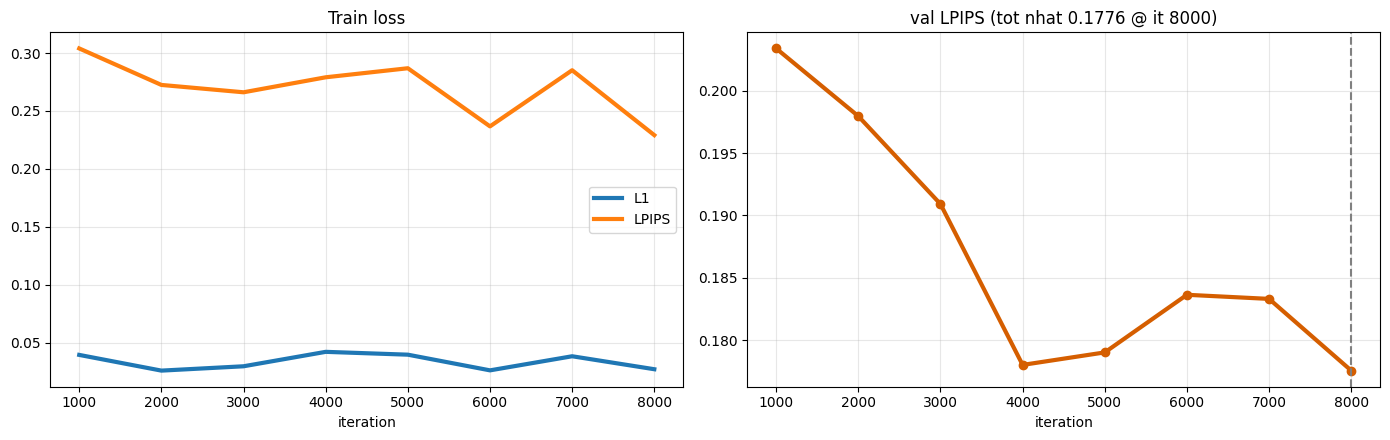

,it,pix,lpips,val
2,3000,0.0296,0.2661,0.1909
3,4000,0.0421,0.2791,0.1780
4,5000,0.0397,0.2869,0.1790
5,6000,0.0261,0.2367,0.1836
6,7000,0.0383,0.2852,0.1833
7,8000,0.0271,0.2291,0.1776


[3.35h / 11.0h] huan luyen xong


True

In [6]:
import lpips
lp_vgg=lpips.LPIPS(net="vgg", verbose=False).to(DEVICE).eval()
for p in lp_vgg.parameters(): p.requires_grad_(False)

def ragan_d(Cr,Cf):
    return (F.binary_cross_entropy_with_logits(Cr-Cf.mean(), torch.ones_like(Cr))+
            F.binary_cross_entropy_with_logits(Cf-Cr.mean(), torch.zeros_like(Cf)))*0.5
def ragan_g(Cr,Cf):
    return (F.binary_cross_entropy_with_logits(Cr-Cf.mean(), torch.zeros_like(Cr))+
            F.binary_cross_entropy_with_logits(Cf-Cr.mean(), torch.ones_like(Cf)))*0.5

optG=torch.optim.Adam(G.parameters(), lr=CFG["lr_G"], betas=(0.9,0.99))
optD=torch.optim.Adam(D.parameters(), lr=CFG["lr_D"], betas=(0.9,0.99))
schedG=torch.optim.lr_scheduler.CosineAnnealingLR(optG, T_max=CFG["iters"], eta_min=1e-6)
scaler=torch.amp.GradScaler("cuda")
G_ema=deepcopy(G).eval()
for p in G_ema.parameters(): p.requires_grad_(False)

@torch.no_grad()
def update_ema(ema, m, decay=0.999):
    for pe,pm in zip(ema.parameters(), m.parameters()):
        pe.mul_(decay).add_(pm.detach(), alpha=1-decay)
    for be,bm in zip(ema.buffers(), m.buffers()): be.copy_(bm)

CKF=CK/"sr_h265_x4.pt"; it0=0; hist=[]
if CKF.exists():
    s=torch.load(CKF, map_location=DEVICE)
    G.load_state_dict(s["G"]); G_ema.load_state_dict(s["G_ema"]); D.load_state_dict(s["D"])
    optG.load_state_dict(s["optG"]); optD.load_state_dict(s["optD"])
    it0=s["it"]; hist=s["hist"]; print(f"resume tu {it0}")

@torch.no_grad()
def validate(m, n=8):
    m.eval(); v=[]
    for k,(x,y,_) in enumerate(val_dl):
        if k>=n: break
        x,y=x.to(DEVICE),y.to(DEVICE)
        with torch.autocast("cuda", torch.float16):
            o=m(x).float().clamp(0,1)
        v.append(lp_vgg(o*2-1, y*2-1).mean().item())
    m.train(); return float(np.mean(v))

WARM=int(CFG["iters"]*0.1)
G.train(); D.train()
t0=time.time(); it=it0; di=iter(train_dl)
pbar=tqdm(total=CFG["iters"], initial=it0, desc="train x4")
while it<CFG["iters"]:
    if (time.time()-t0)/3600>CFG["train_hours"]:
        print(f"\nHet ngan sach train, dung o {it}"); break
    if elapsed_h()>BUDGET_H-1.5:
        print(f"\nGan het ngan sach tong, dung o {it}"); break
    try: x,y,_=next(di)
    except StopIteration: di=iter(train_dl); x,y,_=next(di)
    x,y=x.to(DEVICE,non_blocking=True), y.to(DEVICE,non_blocking=True)
    gan = it>=WARM

    if gan:
        with torch.autocast("cuda", torch.float16):
            with torch.no_grad(): fk=G(x)
            lossD=ragan_d(D(y), D(fk.detach()))
        optD.zero_grad(set_to_none=True); scaler.scale(lossD).backward(); scaler.step(optD)

    with torch.autocast("cuda", torch.float16):
        fake=G(x)
        l_pix=F.l1_loss(fake,y)
        l_per=lp_vgg(fake.clamp(0,1)*2-1, y*2-1).mean()
        lossG=l_pix+CFG["lam_lpips"]*l_per
        l_adv=0.
        if gan:
            l_adv=ragan_g(D(y).detach(), D(fake))
            lossG=lossG+CFG["lam_adv"]*l_adv
    optG.zero_grad(set_to_none=True)
    scaler.scale(lossG).backward(); scaler.step(optG); scaler.update()
    schedG.step(); update_ema(G_ema,G)

    it+=1; pbar.update(1)
    if it%CFG["log_every"]==0:
        pbar.set_postfix(pix=f"{l_pix.item():.4f}", lpips=f"{l_per.item():.4f}",
                         adv=f"{float(l_adv):.3f}" if gan else "-")
    if it%CFG["ckpt_every"]==0 or it==CFG["iters"]:
        vl=validate(G_ema)
        hist.append(dict(it=it, pix=l_pix.item(), lpips=l_per.item(), val=vl))
        torch.save(dict(G=G.state_dict(), G_ema=G_ema.state_dict(), D=D.state_dict(),
                        optG=optG.state_dict(), optD=optD.state_dict(),
                        it=it, hist=hist), CKF)
        print(f"  [it {it}] val LPIPS {vl:.4f}")
pbar.close(); G_ema.eval()
torch.save(dict(G=G.state_dict(), G_ema=G_ema.state_dict(), D=D.state_dict(),
                optG=optG.state_dict(), optD=optD.state_dict(), it=it, hist=hist), CKF)

if hist:
    h=pd.DataFrame(hist)
    fig,ax=plt.subplots(1,2,figsize=(14,4.5))
    ax[0].plot(h["it"],h["pix"],lw=3,label="L1"); ax[0].plot(h["it"],h["lpips"],lw=3,label="LPIPS")
    ax[0].legend(); ax[0].set_title("Train loss"); ax[0].grid(alpha=.3)
    ax[1].plot(h["it"],h["val"],lw=3,color="#D55E00",marker="o")
    b=h.loc[h["val"].idxmin()]
    ax[1].axvline(b["it"],ls="--",color="gray")
    ax[1].set_title(f"val LPIPS (tot nhat {b['val']:.4f} @ it {int(b['it'])})"); ax[1].grid(alpha=.3)
    for a in ax: a.set_xlabel("iteration")
    plt.tight_layout(); plt.savefig(FG/"train_x4.png", dpi=160); plt.show()
    display(h.tail(6).round(4))
check_budget("huan luyen xong")

---
## Phần 5 — Đánh giá

### Cell dưới làm gì?
So sánh bốn phương pháp trên clip validation ở nhiều bitrate, rồi tính BD-rate.

### Bốn phương pháp

| | Mô tả |
|---|---|
| **A** | H.265 1080p — baseline |
| **B** | 270p + bicubic — baseline yếu |
| **C** | 270p + Real-ESRGAN x4plus pretrained |
| **E** | 270p + model vừa fine-tune |

### Cách đọc kết quả

Con số quyết định là **BD-rate LPIPS của E so với A**:

| Kết quả | Kết luận |
|---|---|
| E âm rõ (như −67% ở ×2) | Phương pháp là yếu tố chính, tỉ lệ không quan trọng lắm |
| E dương hoặc gần 0 | **Trần độ phân giải là yếu tố chính** — −67% ở notebook 2 phần lớn nhờ chọn ×2 |

Thêm một chỉ số phụ đáng nhìn: **LPIPS cải thiện bao nhiêu lần khi bitrate tăng từ 200 lên 3000**. Ở notebook video SR, H.265 cải thiện 3,7 lần còn SR chỉ 1,4 lần — đó là dấu vân tay của trần độ phân giải. Nếu bản ×4 này lặp lại tỉ lệ tương tự thì giả thuyết được xác nhận.

In [7]:
from skimage.metrics import structural_similarity
lp_alex=lpips.LPIPS(net="alex", verbose=False).to(DEVICE).eval()

def to_y(b): return cv2.cvtColor(b,cv2.COLOR_BGR2YCrCb)[:,:,0].astype(np.float64)
def psnr_y(a,b):
    m=np.mean((to_y(a)-to_y(b))**2); return 99.0 if m==0 else 10*np.log10(255.0**2/m)
def ssim_y(a,b): return structural_similarity(to_y(a),to_y(b),data_range=255.0)
@torch.no_grad()
def lpd(a,b):
    t=lambda im: torch.from_numpy(np.ascontiguousarray(im[:,:,::-1]).astype(np.float32)/127.5-1
                                  ).permute(2,0,1)[None].to(DEVICE)
    return lp_alex(t(a),t(b)).item()
def kbps_of(p):
    d=float(run(f'ffprobe -v error -show_entries format=duration -of csv=p=0 "{p}"').strip())
    return os.path.getsize(p)*8/d/1000

@torch.no_grad()
def sr_dir(model, lrd, outd, tile=192, pad=12):
    outd=Path(outd); shutil.rmtree(outd, ignore_errors=True); outd.mkdir(parents=True)
    fs=sorted(Path(lrd).glob("*.png")); t0=time.perf_counter()
    for f in fs:
        im=cv2.imread(str(f))[:,:,::-1].astype(np.float32)/255.
        x=torch.from_numpy(np.ascontiguousarray(im)).permute(2,0,1)[None].to(DEVICE)
        _,_,h,w=x.shape; out=torch.zeros(1,3,h*S,w*S,device=DEVICE)
        for y0 in range(0,h,tile):
            for x0 in range(0,w,tile):
                y1,x1=min(y0+tile,h),min(x0+tile,w)
                py0,px0=max(y0-pad,0),max(x0-pad,0); py1,px1=min(y1+pad,h),min(x1+pad,w)
                with torch.autocast("cuda", torch.float16):
                    o=model(x[:,:,py0:py1,px0:px1]).float()
                out[:,:,y0*S:y1*S,x0*S:x1*S]=o[:,:,(y0-py0)*S:(y1-py0)*S,(x0-px0)*S:(x1-px0)*S]
        a=out[0].clamp(0,1).permute(1,2,0).cpu().numpy()[:,:,::-1]
        cv2.imwrite(str(outd/f.name), (a*255).round().astype(np.uint8))
    return len(fs)/(time.perf_counter()-t0)

rows=[]
G_eval=deepcopy(G_ema).eval()
G_pre=build_G(True).eval()
for c in VAL:
    gtf=sorted((DATA/f"gt{c['id']:02d}").glob("*.png"))
    gtt=[]; pg=None
    for f in gtf:
        g=cv2.imread(str(f))
        if pg is not None: gtt.append(lpd(g,pg))
        pg=g
    def ev(fd):
        ps,ss,ls,tl=[],[],[],[]; po=None
        for i,f in enumerate(sorted(Path(fd).glob("*.png"))):
            if i>=len(gtf): break
            o=cv2.imread(str(f)); g=cv2.imread(str(gtf[i]))
            ps.append(psnr_y(o,g)); ss.append(ssim_y(o,g)); ls.append(lpd(o,g))
            if po is not None: tl.append(abs(lpd(o,po)-gtt[i-1]))
            po=o
        return dict(psnr_y=np.mean(ps), ssim=np.mean(ss), lpips=np.mean(ls),
                    tlp=np.mean(tl) if tl else np.nan)

    for br in tqdm(CFG["eval_bitrates"], desc=f"clip{c['id']}"):
        va=EV/f"A_c{c['id']}_{br}.mp4"
        if not va.exists():
            run(f'ffmpeg -y -loglevel error -i "{c["path"]}" -c:v libx265 -preset medium '
                f'-b:v {br}k -maxrate {int(br*1.5)}k -bufsize {br*3}k '
                f'-x265-params log-level=error -pix_fmt yuv420p -an "{va}"', 900)
        da=extract(va, EV/f"A_c{c['id']}_{br}")
        rows.append(dict(clip=c["id"], method="A: H.265 1080p", target=br,
                         kbps=kbps_of(va), fps=np.nan, **ev(da)))

        vl=EV/f"LR_c{c['id']}_{br}.mp4"
        if not vl.exists():
            run(f'ffmpeg -y -loglevel error -i "{c["path"]}" '
                f'-vf "scale={LRW}:{LRH}:flags=lanczos" -c:v libx265 -preset medium '
                f'-b:v {br}k -maxrate {int(br*1.5)}k -bufsize {br*3}k '
                f'-x265-params log-level=error -pix_fmt yuv420p -an "{vl}"', 900)
        lrk=kbps_of(vl); dlr=extract(vl, EV/f"LR_c{c['id']}_{br}")

        db=extract(vl, EV/f"B_c{c['id']}_{br}", vf=f"scale={HRW}:{HRH}:flags=bicubic")
        rows.append(dict(clip=c["id"], method="B: 270p + Bicubic", target=br,
                         kbps=lrk, fps=np.nan, **ev(db)))
        for tag,m in [("C: 270p + ESRGAN x4 goc", G_pre), ("E: 270p + SR khop H.265", G_eval)]:
            od=EV/f"{tag[0]}_c{c['id']}_{br}"
            f_=sr_dir(m, dlr, od)
            rows.append(dict(clip=c["id"], method=tag, target=br, kbps=lrk, fps=f_, **ev(od)))

RES=pd.DataFrame(rows); RES.to_csv(DRIVE/"results_x4"/"results_x4.csv", index=False)
M=RES.groupby(["method","target"])[["psnr_y","ssim","lpips","tlp","fps"]].mean().round(4)
display(M)
check_budget("danh gia xong")

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:02<00:00, 122MB/s]


clip3:   0%|          | 0/5 [00:00<?, ?it/s]

clip4:   0%|          | 0/5 [00:00<?, ?it/s]

psnr_y    ssim   lpips     tlp     fps
method                  target                                         
A: H.265 1080p          200     32.0254  0.8631  0.2638  0.0124     NaN
                        400     35.1158  0.9119  0.1754  0.0073     NaN
                        800     37.8729  0.9437  0.1117  0.0058     NaN
                        1500    39.8163  0.9605  0.0739  0.0057     NaN
                        3000    41.5074  0.9716  0.0478  0.0054     NaN
B: 270p + Bicubic       200     31.9548  0.8359  0.3028  0.0096     NaN
                        400     32.8829  0.8528  0.2733  0.0100     NaN
                        800     33.4012  0.8634  0.2515  0.0101     NaN
                        1500    33.6483  0.8694  0.2383  0.0098     NaN
                        3000    33.8043  0.8731  0.2296  0.0089     NaN
C: 270p + ESRGAN x4 goc 200     30.2386  0.8148  0.1937  0.0058  1.0017
                        400     30.6868  0.8237  0.1775  0.0048  1.0071
                        800     30.8409  0.8290  0.1667  0.0046  1.0029
                        1500    30.9007  0.8326  0.1641  0.0045  0.9977
                        3000    30.9151  0.8349  0.1622  0.0046  1.0001
E: 270p + SR khop H.265 200     32.0662  0.8353  0.1665  0.0081  1.0095
                        400     33.1802  0.8547  0.1448  0.0070  1.0081
                        800     33.7732  0.8655  0.1291  0.0068  1.0080
                        1500    34.0292  0.8708  0.1209  0.0065  1.0021
                        3000    34.1588  0.8734  0.1173  0.0060  1.0086

[5.48h / 11.0h] danh gia xong


True

### Cell dưới làm gì?
Tính BD-rate, vẽ đường cong, và in kết luận về giả thuyết trần độ phân giải.

### Tại sao cần?
Đây là nơi trả lời câu hỏi của notebook. Cell in thẳng ra kết luận nào được số liệu ủng hộ.

BD-rate so voi A: H.265 1080p (am = tiet kiem bitrate)


,LPIPS,PSNR
B: 270p + Bicubic,375.2,124.7
C: 270p + ESRGAN x4 goc,36.7,NaN
E: 270p + SR khop H.265,0.9,106.2


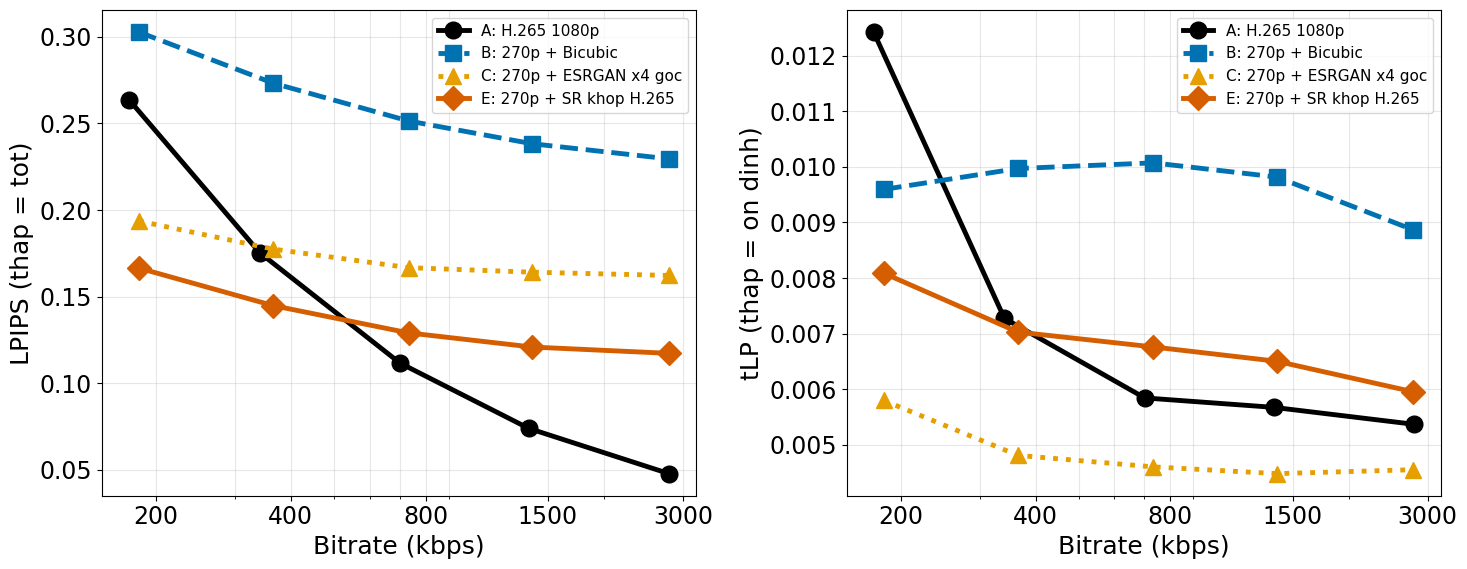


KIEM CHUNG GIA THUYET TRAN DO PHAN GIAI

LPIPS cai thien khi bitrate tang 200 -> 3000 kbps (15.0 lan):
  A: H.265 1080p               0.2638 -> 0.0478  = 5.5 lan
  B: 270p + Bicubic            0.3028 -> 0.2296  = 1.3 lan
  C: 270p + ESRGAN x4 goc      0.1937 -> 0.1622  = 1.2 lan
  E: 270p + SR khop H.265      0.1665 -> 0.1173  = 1.4 lan

BD-rate LPIPS: C = +36.7%  ->  E = +0.9%
Fine-tune cai thien 35.8 diem phan tram

Doi chieu voi notebook 2 (x2): C = +84%, E = -67.2%

>>> E THUA baseline o x4, du van cai thien manh so voi C.
    -> Tran do phan giai la yeu to chinh. Ket qua -67.2% cua notebook 2
       chi dung cho x2, khong tong quat sang x4.
    -> Phat bieu dung: 'o ti le x2, train khop degradation cho -67% BD-rate'

Ket qua luu tai /content/drive/MyDrive/CS232/results_x4
  bdrate_x4.csv                      0.00 MB
  rd_x4.png                          0.22 MB
  results_x4.csv                     0.01 MB
  train_x4.png                       0.09 MB


In [8]:
def bd_rate(R1,D1,R2,D2,higher=True):
    R1,D1,R2,D2=map(np.asarray,(R1,D1,R2,D2))
    if not higher: D1,D2=-D1,-D2
    o1,o2=np.argsort(D1),np.argsort(D2); D1,R1,D2,R2=D1[o1],R1[o1],D2[o2],R2[o2]
    deg=min(3,len(R1)-1,len(R2)-1)
    if deg<1: return float("nan")
    p1=np.polyfit(D1,np.log10(R1),deg); p2=np.polyfit(D2,np.log10(R2),deg)
    lo,hi=max(D1.min(),D2.min()),min(D1.max(),D2.max())
    if hi<=lo: return float("nan")
    P1,P2=np.polyint(p1),np.polyint(p2)
    a=((np.polyval(P2,hi)-np.polyval(P2,lo))-(np.polyval(P1,hi)-np.polyval(P1,lo)))/(hi-lo)
    return (10**a-1)*100

g=RES.groupby(["method","target"])[["kbps","lpips","psnr_y"]].mean().reset_index()
A=g[g.method.str.startswith("A")].sort_values("kbps")
BD={}
for m in sorted(g.method.unique()):
    if m.startswith("A"): continue
    h=g[g.method==m].sort_values("kbps")
    BD[m]=dict(LPIPS=bd_rate(A.kbps,A.lpips,h.kbps,h.lpips,False),
               PSNR=bd_rate(A.kbps,A.psnr_y,h.kbps,h.psnr_y,True))
BD=pd.DataFrame(BD).T
print("BD-rate so voi A: H.265 1080p (am = tiet kiem bitrate)")
display(BD.round(1))
BD.to_csv(DRIVE/"results_x4"/"bdrate_x4.csv")

plt.rcParams.update({"font.size":17,"axes.labelsize":18,"lines.linewidth":3.5,"lines.markersize":12})
ST={"A: H.265 1080p":dict(color="#000000",marker="o"),
    "B: 270p + Bicubic":dict(color="#0072B2",marker="s",ls="--"),
    "C: 270p + ESRGAN x4 goc":dict(color="#E69F00",marker="^",ls=":"),
    "E: 270p + SR khop H.265":dict(color="#D55E00",marker="D")}
fig,ax=plt.subplots(1,2,figsize=(15,6))
for met,lab,axi,hb in [("lpips","LPIPS (thap = tot)",ax[0],False),
                       ("tlp","tLP (thap = on dinh)",ax[1],False)]:
    for m,gg in RES.groupby("method"):
        gg=gg.groupby("target")[[met,"kbps"]].mean().reset_index().sort_values("kbps")
        axi.plot(gg.kbps, gg[met], label=m, **ST.get(m,{}))
    axi.set_xscale("log"); axi.set_xlabel("Bitrate (kbps)"); axi.set_ylabel(lab)
    xt=sorted(RES.target.unique()); axi.set_xticks(xt); axi.set_xticklabels([str(x) for x in xt])
    axi.xaxis.set_minor_formatter(plt.NullFormatter()); axi.grid(which="both",alpha=.3)
    axi.legend(fontsize=11)
plt.tight_layout(); plt.savefig(FG/"rd_x4.png", dpi=170); plt.show()
shutil.copy(FG/"rd_x4.png", DRIVE/"results_x4")

print("\n"+"="*66)
print("KIEM CHUNG GIA THUYET TRAN DO PHAN GIAI")
print("="*66)
lo_br, hi_br = CFG["eval_bitrates"][0], CFG["eval_bitrates"][-1]
print(f"\nLPIPS cai thien khi bitrate tang {lo_br} -> {hi_br} kbps ({hi_br/lo_br:.1f} lan):")
for m in sorted(g.method.unique()):
    h=g[g.method==m].sort_values("target")
    r=h.lpips.iloc[0]/h.lpips.iloc[-1]
    print(f"  {m:28s} {h.lpips.iloc[0]:.4f} -> {h.lpips.iloc[-1]:.4f}  = {r:.1f} lan")

e_bd=BD.loc["E: 270p + SR khop H.265","LPIPS"]
c_bd=BD.loc["C: 270p + ESRGAN x4 goc","LPIPS"]
print(f"\nBD-rate LPIPS: C = {c_bd:+.1f}%  ->  E = {e_bd:+.1f}%")
print(f"Fine-tune cai thien {c_bd-e_bd:.1f} diem phan tram\n")
print("Doi chieu voi notebook 2 (x2): C = +84%, E = -67.2%\n")
if e_bd < -20:
    print(">>> E VAN THANG o x4. Phuong phap la yeu to chinh, khong phai ti le phong.")
elif e_bd < 0:
    print(">>> E thang nhung yeu hon nhieu so voi x2. CA HAI yeu to deu dong gop.")
else:
    print(">>> E THUA baseline o x4, du van cai thien manh so voi C.")
    print("    -> Tran do phan giai la yeu to chinh. Ket qua -67.2% cua notebook 2")
    print("       chi dung cho x2, khong tong quat sang x4.")
    print("    -> Phat bieu dung: 'o ti le x2, train khop degradation cho -67% BD-rate'")

OUT=DRIVE/"results_x4"
for f in FG.glob("*.png"): shutil.copy(f, OUT)
print(f"\nKet qua luu tai {OUT}")
for f in sorted(OUT.iterdir()): print(f"  {f.name:32s} {os.path.getsize(f)/1e6:6.2f} MB")

---
## Phần 6 — Xuất video so sánh

### Cell dưới làm gì?
Ghép bốn phương pháp cạnh nhau thành video, và xuất từng phương pháp thành video riêng.

### Tại sao cần?
Ở ×4, khác biệt giữa "mờ do thiếu độ phân giải" và "mờ do nén" rất khó thấy trên ảnh tĩnh. Video cho thấy rõ hơn, nhất là ở vùng texture.

Điều cần quan sát: ở bitrate cao, cột E có còn thua cột A rõ rệt không. Nếu có, đó là bằng chứng trực quan cho trần độ phân giải — model đã hết artifact để sửa mà vẫn không đuổi kịp, vì đơn giản là thiếu pixel.

In [9]:
def export_compare(clip_id, br, crop=480):
    cols=[("Ground truth", DATA/f"gt{clip_id:02d}"),
          ("A: H.265 1080p", EV/f"A_c{clip_id}_{br}"),
          ("C: ESRGAN x4 goc", EV/f"C_c{clip_id}_{br}"),
          ("E: khop H.265", EV/f"E_c{clip_id}_{br}")]
    cols=[(t,Path(d)) for t,d in cols if Path(d).exists()]
    if len(cols)<2: print(f"  bo qua c{clip_id}@{br}"); return None
    gts=sorted(cols[0][1].glob("*.png"))
    g0=cv2.cvtColor(cv2.imread(str(gts[0])),cv2.COLOR_BGR2GRAY)
    best,pos=-1,(0,0)
    for y in range(0,max(1,g0.shape[0]-crop),120):
        for x in range(0,max(1,g0.shape[1]-crop),120):
            v=cv2.Laplacian(g0[y:y+crop,x:x+crop],cv2.CV_64F).var()
            if v>best: best,pos=v,(y,x)
    y0,x0=pos
    tmp=EV/f"tmp_{clip_id}_{br}"; shutil.rmtree(tmp,ignore_errors=True); tmp.mkdir(parents=True)
    n=0
    for k in range(len(gts)):
        tiles=[]
        for title,d in cols:
            f=d/gts[k].name
            if not f.exists(): break
            im=cv2.imread(str(f))
            if im is None: break
            t=im[y0:y0+crop, x0:x0+crop].copy()
            cv2.rectangle(t,(0,0),(crop,46),(0,0,0),-1)
            cv2.putText(t,title,(10,32),cv2.FONT_HERSHEY_SIMPLEX,0.75,(255,255,255),2,cv2.LINE_AA)
            tiles.append(t)
        if len(tiles)==len(cols):
            cv2.imwrite(str(tmp/f"{k+1:04d}.png"), np.concatenate(tiles,axis=1)); n+=1
    out=DRIVE/"results_x4"/f"compare_x4_c{clip_id}_{br}kbps.mp4"
    run(f'ffmpeg -y -loglevel error -framerate {CFG["fps"]} -i "{tmp}"/%04d.png '
        f'-c:v libx264 -crf 14 -pix_fmt yuv420p "{out}"', 900)
    shutil.rmtree(tmp, ignore_errors=True)
    print(f"  {out.name}: {n} frame, {os.path.getsize(out)/1e6:.1f} MB")
    return out

def export_single(clip_id, br):
    for tag,d in [("GT",DATA/f"gt{clip_id:02d}"), ("A_h265",EV/f"A_c{clip_id}_{br}"),
                  ("C_pretrained",EV/f"C_c{clip_id}_{br}"), ("E_finetuned",EV/f"E_c{clip_id}_{br}")]:
        d=Path(d)
        if not d.exists(): continue
        out=DRIVE/"results_x4"/f"{tag}_c{clip_id}_{br}kbps.mp4"
        run(f'ffmpeg -y -loglevel error -framerate {CFG["fps"]} -i "{d}"/%04d.png '
            f'-c:v libx264 -crf 14 -pix_fmt yuv420p "{out}"', 900)
        print(f"  {out.name}  {os.path.getsize(out)/1e6:.1f} MB")

print("Video ghep 4 cot:")
for c in VAL:
    for br in [CFG["eval_bitrates"][0], CFG["eval_bitrates"][-1]]:
        export_compare(c["id"], br)
print("\nVideo rieng le (clip val dau tien, bitrate thap nhat):")
export_single(VAL[0]["id"], CFG["eval_bitrates"][0])
print(f"\nTong thoi gian: {elapsed_h():.1f}h")

Video ghep 4 cot:
  compare_x4_c3_200kbps.mp4: 144 frame, 4.1 MB
  compare_x4_c3_3000kbps.mp4: 144 frame, 4.0 MB
  compare_x4_c4_200kbps.mp4: 144 frame, 13.4 MB
  compare_x4_c4_3000kbps.mp4: 144 frame, 15.8 MB

Video rieng le (clip val dau tien, bitrate thap nhat):
  GT_c3_200kbps.mp4  7.5 MB
  A_h265_c3_200kbps.mp4  5.2 MB
  C_pretrained_c3_200kbps.mp4  9.0 MB
  E_finetuned_c3_200kbps.mp4  6.3 MB

Tong thoi gian: 5.6h


---
## Ghi chú cho báo cáo

Notebook này là một **thí nghiệm khử biến**, và kết quả nào cũng dùng được:

**Nếu E thắng baseline ở ×4** — phát biểu "train khớp degradation cho −67% BD-rate" là tổng quát, không phụ thuộc tỉ lệ. Báo cáo giữ nguyên.

**Nếu E thua baseline ở ×4** — phát biểu phải thêm điều kiện: *"ở tỉ lệ ×2"*. Và bạn có thêm một phát hiện: tồn tại một **trần chất lượng do độ phân giải**, khiến pipeline SR ngừng cải thiện khi bitrate vượt một ngưỡng, trong khi codec thuần thì không.

Chỉ số định lượng cho trần đó là **tỉ lệ cải thiện LPIPS theo bitrate**, cell phần 5 in ra sẵn. Nếu H.265 cải thiện nhanh hơn SR nhiều lần thì trần là có thật.

Đây là loại phát hiện có giá trị hơn một con số đẹp: nó cho biết phương pháp dùng được ở đâu và hết tác dụng từ đâu.